# 01 — EDA: Canary Islands Tourism Forecast

Primer paso real: descargar el cubo `C00065A_000003` del ISTAC (ver
`data/README.md`), inspeccionar las columnas exactas del export, y escribir
aquí el parser de armonización hacia el esquema de `src/data.py`
(`fecha`, `isla`, `pernoctaciones`, `viajeros`, `adr_eur`, `revpar_eur`,
`grado_ocupacion`).

Preguntas guía una vez armonizado:
- ¿Qué isla tiene mayor/menor estacionalidad?
- ¿Se confirma la doble temporada alta (invierno + verano) que asume
  `HIGH_SEASON_MONTHS` en `src/features.py`, o los datos dicen otra cosa?
- ¿Hay una ruptura visible en 2020-2021 (covid) que haya que tratar aparte?
- ¿ADR y ocupación se mueven juntos o hay islas donde compensan uno al otro?

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

raw = pd.read_csv("data/raw/C00065A_000003.csv")
print(raw.shape)
raw.head()

(596736, 14)


,TIME_PERIOD#es,TIME_PERIOD_CODE,TERRITORIO#es,TERRITORIO_CODE,MEDIDAS#es,MEDIDAS_CODE,ALOJAMIENTO_TURISTICO_CATEGORIA#es,ALOJAMIENTO_TURISTICO_CATEGORIA_CODE,OBS_VALUE,NOTAS_OBSERVACION#es,CONFIDENCIALIDAD_OBSERVACION#es,CONFIDENCIALIDAD_OBSERVACION_CODE,ESTADO_OBSERVACION#es,ESTADO_OBSERVACION_CODE
0,01/2009,2009-M01,Canarias,ES70,Ingresos por habitación,REVPAR,Total,_T,48.05,NaN,NaN,NaN,NaN,NaN
1,02/2009,2009-M02,Canarias,ES70,Ingresos por habitación,REVPAR,Total,_T,43.83,NaN,NaN,NaN,NaN,NaN
2,03/2009,2009-M03,Canarias,ES70,Ingresos por habitación,REVPAR,Total,_T,46.44,NaN,NaN,NaN,NaN,NaN
3,04/2009,2009-M04,Canarias,ES70,Ingresos por habitación,REVPAR,Total,_T,43.95,NaN,NaN,NaN,NaN,NaN
4,05/2009,2009-M05,Canarias,ES70,Ingresos por habitación,REVPAR,Total,_T,32.73,NaN,NaN,NaN,NaN,NaN


## Columnas reales del export

El cubo llega en formato SDMX/JSON-stat aplanado: una fila por
`(periodo, territorio, medida, categoría de alojamiento)`. Para nuestro caso:

- `TERRITORIO#es` — incluye islas, municipios y el total "Canarias" en la
  misma columna. Filtramos a los 7 nombres de isla exactos de `src/data.py`.
- `MEDIDAS#es` — contiene 8 medidas distintas (ingresos, tarifa media diaria,
  varios ratios de empleo). Usamos solo `Tarifa media diaria` (ADR) e
  `Ingresos por habitación` (RevPAR).
- `ALOJAMIENTO_TURISTICO_CATEGORIA#es` — desagrega por categoría de estrellas;
  usamos `Total` para no perder cobertura de establecimientos.
- `TIME_PERIOD_CODE` — mezcla periodos anuales (`"2009"`) y mensuales
  (`"2009-M01"`) en la misma columna. Filtramos solo los mensuales.

No hay una medida directa de ocupación en este cubo (esa vendría del cubo
`_000040`/`_000060` de pernoctaciones/viajeros, que no traen ADR/RevPAR
mensual — ver `data/README.md`). Como el propio `src/business.py` ya asume
`RevPAR = ADR × Ocupación`, derivamos `grado_ocupacion = revpar_eur / adr_eur`
en vez de dejarla vacía.

In [2]:
from src.data import ISLANDS

MEASURES = {"Tarifa media diaria": "adr_eur", "Ingresos por habitación": "revpar_eur"}

is_monthly = raw["TIME_PERIOD_CODE"].str.contains("-M", na=False)
is_island = raw["TERRITORIO#es"].isin(ISLANDS)
is_total_category = raw["ALOJAMIENTO_TURISTICO_CATEGORIA#es"] == "Total"
is_target_measure = raw["MEDIDAS#es"].isin(MEASURES)

filtered = raw[is_monthly & is_island & is_total_category & is_target_measure].copy()
print(f"{len(raw)} filas crudas -> {len(filtered)} filas tras filtrar")

filtered["fecha"] = pd.to_datetime(filtered["TIME_PERIOD_CODE"], format="%Y-M%m")
filtered["indicador"] = filtered["MEDIDAS#es"].map(MEASURES)
filtered["isla"] = filtered["TERRITORIO#es"]

wide = filtered.pivot_table(index=["fecha", "isla"], columns="indicador", values="OBS_VALUE").reset_index()
wide.columns.name = None
wide["grado_ocupacion"] = wide["revpar_eur"] / wide["adr_eur"]

print(wide.shape)
wide.sort_values(["isla", "fecha"]).head()

596736 filas crudas -> 2870 filas tras filtrar
(1414, 5)


,fecha,isla,adr_eur,revpar_eur,grado_ocupacion
0,2009-01-01,El Hierro,56.55,8.38,0.148187
7,2009-02-01,El Hierro,58.57,10.26,0.175175
14,2009-03-01,El Hierro,60.87,11.75,0.193034
21,2009-04-01,El Hierro,66.49,21.12,0.317642
28,2009-05-01,El Hierro,67.40,14.48,0.214837


In [3]:
print("Meses por isla:")
print(wide.groupby("isla")["fecha"].count())
print()
print("Rango de fechas:", wide["fecha"].min().date(), "->", wide["fecha"].max().date())
print()
print("grado_ocupacion fuera de [0, 1] (posibles anomalías de la fuente):")
anomalias = wide[(wide["grado_ocupacion"] < 0) | (wide["grado_ocupacion"] > 1)]
print(len(anomalias), "filas")
anomalias.sort_values("grado_ocupacion", ascending=False).head()

Meses por isla:
isla
El Hierro        202
Fuerteventura    202
Gran Canaria     202
La Gomera        202
La Palma         202
Lanzarote        202
Tenerife         202
Name: fecha, dtype: int64

Rango de fechas: 2009-01-01 -> 2026-01-01

grado_ocupacion fuera de [0, 1] (posibles anomalías de la fuente):
0 filas


,fecha,isla,adr_eur,revpar_eur,grado_ocupacion


In [4]:
from pathlib import Path

output_path = Path("data/processed/canarias_turismo_mensual.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

final = wide.sort_values(["isla", "fecha"])[["fecha", "isla", "adr_eur", "revpar_eur", "grado_ocupacion"]]
final.to_csv(output_path, index=False)
print(f"Guardado {len(final)} filas en {output_path}")

# Verificar que src/data.py puede cargarlo sin errores
from src.data import load_harmonized_series

df = load_harmonized_series()
df.head()

Guardado 1414 filas en data/processed/canarias_turismo_mensual.csv


,fecha,isla,adr_eur,revpar_eur,grado_ocupacion
0,2009-01-01,El Hierro,56.55,8.38,0.148187
1,2009-02-01,El Hierro,58.57,10.26,0.175175
2,2009-03-01,El Hierro,60.87,11.75,0.193034
3,2009-04-01,El Hierro,66.49,21.12,0.317642
4,2009-05-01,El Hierro,67.40,14.48,0.214837


## Respondiendo a las preguntas guía

1. ¿Qué isla tiene mayor/menor estacionalidad?
2. ¿Se confirma la doble temporada alta (invierno + verano)?
3. ¿Hay una ruptura visible en 2020-2021 (covid)?
4. ¿ADR y ocupación se mueven juntos o compensan?

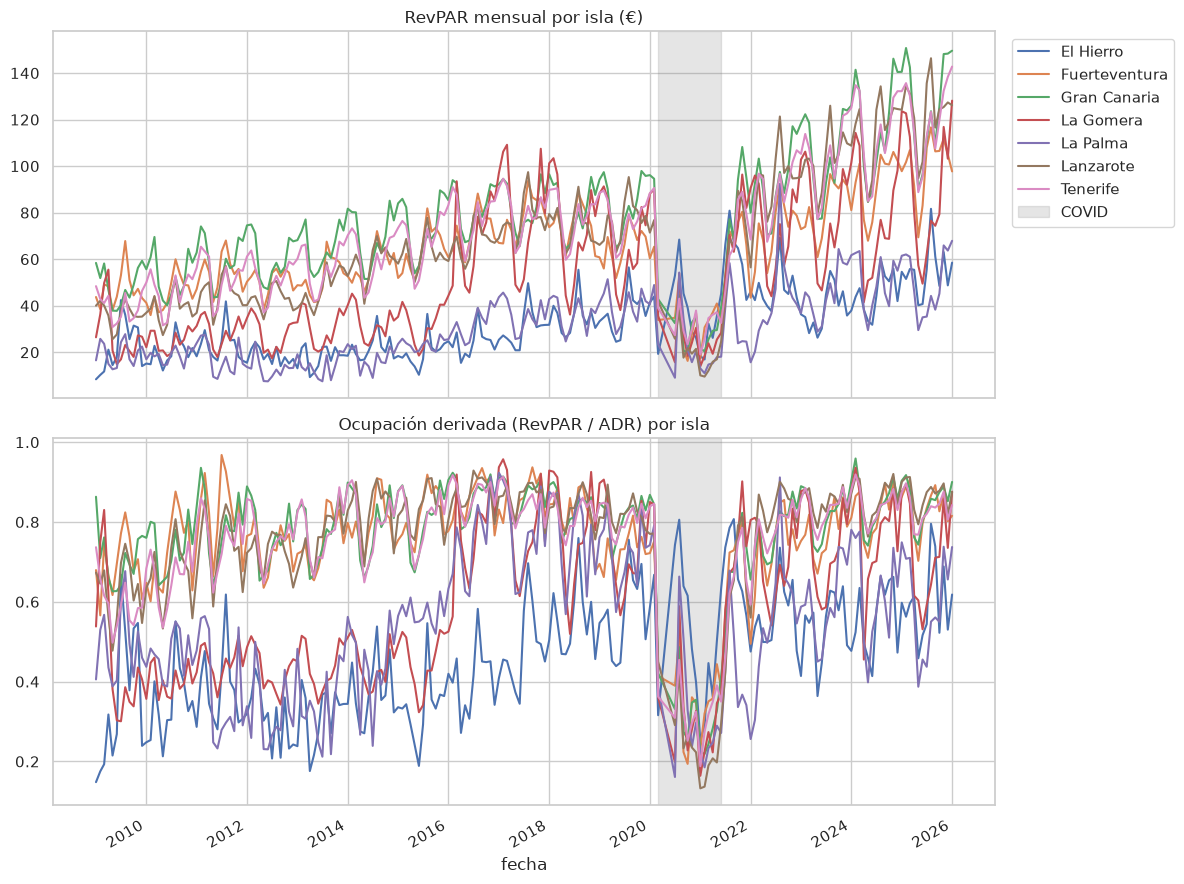

In [5]:
from src.data import to_wide_by_island

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

wide_revpar = to_wide_by_island(df, "revpar_eur")
wide_revpar.plot(ax=axes[0])
axes[0].set_title("RevPAR mensual por isla (€)")
axes[0].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), color="grey", alpha=0.2, label="COVID")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1))

wide_occ = to_wide_by_island(df, "grado_ocupacion")
wide_occ.plot(ax=axes[1], legend=False)
axes[1].set_title("Ocupación derivada (RevPAR / ADR) por isla")
axes[1].axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), color="grey", alpha=0.2)

plt.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("reports/figures/01_revpar_ocupacion_por_isla.png", dpi=110, bbox_inches="tight")
plt.show()

In [6]:
monthly_avg = df.groupby(df["fecha"].dt.month)["grado_ocupacion"].mean()
print("Ocupación media por mes (todas las islas, todos los años):")
print(monthly_avg.round(3))

peak_months = monthly_avg.sort_values(ascending=False).head(4).index.tolist()
print(f"\nMeses de mayor ocupación real: {sorted(peak_months)}")
print("HIGH_SEASON_MONTHS asumidos en src/features.py: {1, 2, 3, 7, 8, 12}")

seasonality_by_island = df.groupby("isla")["grado_ocupacion"].agg(["mean", "std"])
seasonality_by_island["coef_variacion"] = seasonality_by_island["std"] / seasonality_by_island["mean"]
seasonality_by_island.sort_values("coef_variacion", ascending=False)

Ocupación media por mes (todas las islas, todos los años):
fecha
1     0.674
2     0.692
3     0.689
4     0.618
5     0.574
6     0.603
7     0.641
8     0.721
9     0.682
10    0.667
11    0.718
12    0.640
Name: grado_ocupacion, dtype: float64

Meses de mayor ocupación real: [2, 3, 8, 11]
HIGH_SEASON_MONTHS asumidos en src/features.py: {1, 2, 3, 7, 8, 12}


,mean,std,coef_variacion
isla,,,
La Palma,0.542825,0.185529,0.341784
La Gomera,0.591839,0.196969,0.332808
El Hierro,0.458098,0.148707,0.324619
Lanzarote,0.757504,0.164397,0.217025
Tenerife,0.752681,0.144906,0.192520
Gran Canaria,0.770541,0.142977,0.185554
Fuerteventura,0.752964,0.136596,0.181411
